# Weather - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

**Open-Meteo.** A free weather service built for programs rather than people: give it a
latitude, longitude and date range, and it returns decades of daily weather. No account, no
key, no cost. Think of it as: *"the weather history of any point on Earth, as a table."*

- **Explore it in a browser:** <https://open-meteo.com/en/docs/historical-weather-api>
  (a live form: type a city, tick *temperature* and *dew point*, and it builds the exact web
  address that returns the data)
- Research-grade source behind it (ERA5): <https://cds.climate.copernicus.eu/>

> Why weather at all? **Absolute humidity** is the established driver of influenza
> seasonality (Shaman & Kohn 2009; Shaman et al. 2010, 2012). Weather does not count cases;
> it shifts the conditions for transmission.


## Step 1: pull the weather

> *Using the Open-Meteo historical archive API (free, no key), pull daily mean*
> *temperature and dew point for Atlanta (33.749, -84.388) from 2016 to now. Return a*
> *tidy DataFrame and report the date range.*


In [1]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen

import pandas as pd

# Open-Meteo historical archive: daily means at Atlanta, GA.
params = {
    'latitude': 33.749,
    'longitude': -84.388,
    'start_date': '2016-01-01',
    'end_date': pd.Timestamp.now(tz='America/New_York').date().isoformat(),
    'daily': 'temperature_2m_mean,dew_point_2m_mean',
    'timezone': 'America/New_York',
}
url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(params)
with urlopen(url, timeout=120) as response:
    daily = json.load(response)['daily']

# One row per date, with descriptive, analysis-ready column names.
wx = pd.DataFrame({
    'date': pd.to_datetime(daily['time']),
    'temp_c': daily['temperature_2m_mean'],
    'dewpoint_c': daily['dew_point_2m_mean'],
})

print(f'{len(wx):,} daily records: {wx.date.min():%Y-%m-%d} to {wx.date.max():%Y-%m-%d}')
wx.head()


3,855 daily records: 2016-01-01 to 2026-07-21


,date,temp_c,dewpoint_c
0,2016-01-01,7.1,-0.9
1,2016-01-02,4.7,-4.0
2,2016-01-03,5.3,-2.8
3,2016-01-04,3.1,-5.1
4,2016-01-05,0.3,-9.0


## Step 2: compute absolute humidity

> *Compute absolute humidity in g/m^3 from temperature T and dew point Td:*
> *e = 6.112 * exp(17.67*Td/(Td+243.5)); AH = 216.7 * e / (T+273.15). Resample to weekly*
> *and plot it, then plot the mean AH by calendar month.*

**Your check:** does AH bottom out in winter? That is the Shaman result: low absolute
humidity precedes influenza season.


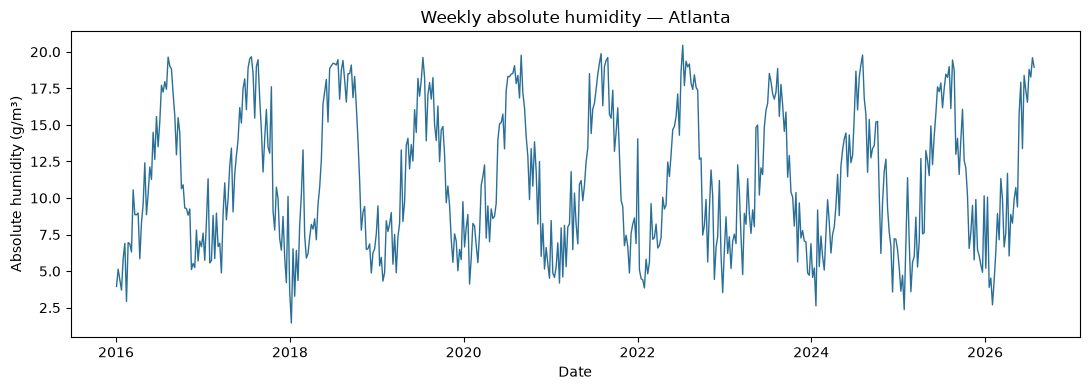

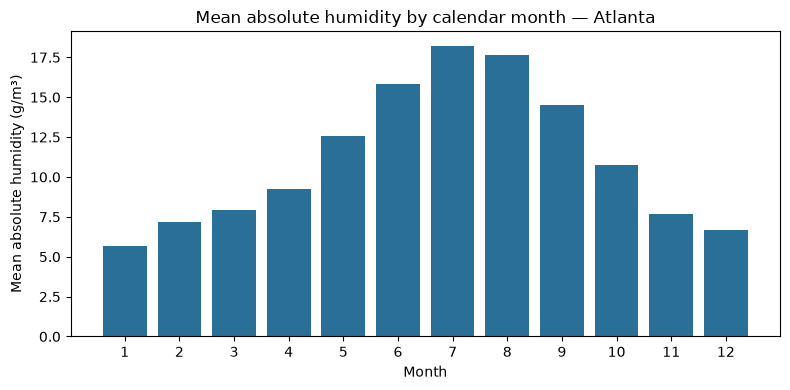

Driest months (mean AH, g/m³):
 month abs_humidity_g_m3
     1              5.68
    12              6.68
     2              7.18


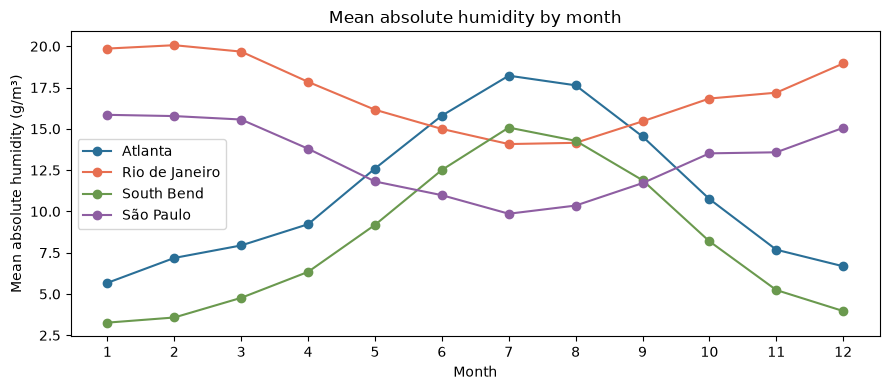

Rio driest months (mean AH, g/m³):
 month abs_humidity_g_m3
     7             14.08
     8             14.15
     6             14.99


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Saturation vapour pressure (hPa), then absolute humidity (g/m^3).
e = 6.112 * np.exp(17.67 * wx['dewpoint_c'] / (wx['dewpoint_c'] + 243.5))
wx['abs_humidity_g_m3'] = 216.7 * e / (wx['temp_c'] + 273.15)

weekly_ah = (wx.set_index('date')['abs_humidity_g_m3']
                .resample('W')
                .mean()
                .reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly_ah['date'], weekly_ah['abs_humidity_g_m3'], lw=1, color='#2A6F97')
ax.set(title='Weekly absolute humidity — Atlanta', xlabel='Date',
       ylabel='Absolute humidity (g/m³)')
fig.tight_layout()
plt.show()

monthly_ah = (wx.assign(month=wx['date'].dt.month)
              .groupby('month', as_index=False)['abs_humidity_g_m3']
              .mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_ah['month'], monthly_ah['abs_humidity_g_m3'], color='#2A6F97')
ax.set(title='Mean absolute humidity by calendar month — Atlanta',
       xlabel='Month', ylabel='Mean absolute humidity (g/m³)', xticks=range(1, 13))
fig.tight_layout()
plt.show()

print('Driest months (mean AH, g/m³):')
print(monthly_ah.nsmallest(3, 'abs_humidity_g_m3').to_string(index=False, formatters={
    'abs_humidity_g_m3': '{:.2f}'.format
}))

# Stretch: compare Rio de Janeiro's absolute-humidity cycle.
rio_params = params | {'latitude': -22.9068, 'longitude': -43.1729}
rio_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(rio_params)
with urlopen(rio_url, timeout=120) as response:
    rio_daily = json.load(response)['daily']

rio = pd.DataFrame({
    'date': pd.to_datetime(rio_daily['time']),
    'temp_c': rio_daily['temperature_2m_mean'],
    'dewpoint_c': rio_daily['dew_point_2m_mean'],
})
rio_e = 6.112 * np.exp(17.67 * rio['dewpoint_c'] / (rio['dewpoint_c'] + 243.5))
rio['abs_humidity_g_m3'] = 216.7 * rio_e / (rio['temp_c'] + 273.15)
rio_monthly_ah = (rio.assign(month=rio['date'].dt.month)
                  .groupby('month', as_index=False)['abs_humidity_g_m3'].mean())

south_bend_params = params | {'latitude': 41.6764, 'longitude': -86.2520}
south_bend_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(south_bend_params)
with urlopen(south_bend_url, timeout=120) as response:
    south_bend_daily = json.load(response)['daily']

south_bend = pd.DataFrame({
    'date': pd.to_datetime(south_bend_daily['time']),
    'temp_c': south_bend_daily['temperature_2m_mean'],
    'dewpoint_c': south_bend_daily['dew_point_2m_mean'],
})
south_bend_e = 6.112 * np.exp(
    17.67 * south_bend['dewpoint_c'] / (south_bend['dewpoint_c'] + 243.5)
)
south_bend['abs_humidity_g_m3'] = 216.7 * south_bend_e / (south_bend['temp_c'] + 273.15)
south_bend_monthly_ah = (south_bend.assign(month=south_bend['date'].dt.month)
                  .groupby('month', as_index=False)['abs_humidity_g_m3'].mean())

sao_paulo_params = params | {'latitude': -23.5505, 'longitude': -46.6333}
sao_paulo_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(sao_paulo_params)
with urlopen(sao_paulo_url, timeout=120) as response:
    sao_paulo_daily = json.load(response)['daily']

sao_paulo = pd.DataFrame({
    'date': pd.to_datetime(sao_paulo_daily['time']),
    'temp_c': sao_paulo_daily['temperature_2m_mean'],
    'dewpoint_c': sao_paulo_daily['dew_point_2m_mean'],
})
sao_paulo_e = 6.112 * np.exp(
    17.67 * sao_paulo['dewpoint_c'] / (sao_paulo['dewpoint_c'] + 243.5)
)
sao_paulo['abs_humidity_g_m3'] = 216.7 * sao_paulo_e / (sao_paulo['temp_c'] + 273.15)
sao_paulo_monthly_ah = (sao_paulo.assign(month=sao_paulo['date'].dt.month)
                  .groupby('month', as_index=False)['abs_humidity_g_m3'].mean())

seattle_params = params | {'latitude': 47.6062, 'longitude': -122.3321}
seattle_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(seattle_params)
with urlopen(seattle_url, timeout=120) as response:
    seattle_daily = json.load(response)['daily']

seattle = pd.DataFrame({
    'date': pd.to_datetime(seattle_daily['time']),
    'temp_c': seattle_daily['temperature_2m_mean'],
    'dewpoint_c': seattle_daily['dew_point_2m_mean'],
})
seattle_e = 6.112 * np.exp(17.67 * seattle['dewpoint_c'] / (seattle['dewpoint_c'] + 243.5))
seattle['abs_humidity_g_m3'] = 216.7 * seattle_e / (seattle['temp_c'] + 273.15)
seattle_monthly_ah = (seattle.assign(month=seattle['date'].dt.month)
                  .groupby('month', as_index=False)['abs_humidity_g_m3'].mean())

recife_params = params | {'latitude': -8.0476, 'longitude': -34.8770}
recife_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(recife_params)
with urlopen(recife_url, timeout=120) as response:
    recife_daily = json.load(response)['daily']

recife = pd.DataFrame({
    'date': pd.to_datetime(recife_daily['time']),
    'temp_c': recife_daily['temperature_2m_mean'],
    'dewpoint_c': recife_daily['dew_point_2m_mean'],
})
recife_e = 6.112 * np.exp(17.67 * recife['dewpoint_c'] / (recife['dewpoint_c'] + 243.5))
recife['abs_humidity_g_m3'] = 216.7 * recife_e / (recife['temp_c'] + 273.15)
recife_monthly_ah = (recife.assign(month=recife['date'].dt.month)
                  .groupby('month', as_index=False)['abs_humidity_g_m3'].mean())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_ah['month'], monthly_ah['abs_humidity_g_m3'], marker='o',
        label='Atlanta', color='#2A6F97')
ax.plot(rio_monthly_ah['month'], rio_monthly_ah['abs_humidity_g_m3'], marker='o',
        label='Rio de Janeiro', color='#E76F51')
ax.plot(south_bend_monthly_ah['month'], south_bend_monthly_ah['abs_humidity_g_m3'],
        marker='o', label='South Bend', color='#6A994E')
ax.plot(sao_paulo_monthly_ah['month'], sao_paulo_monthly_ah['abs_humidity_g_m3'],
        marker='o', label='São Paulo', color='#8E5EA2')
ax.plot(seattle_monthly_ah['month'], seattle_monthly_ah['abs_humidity_g_m3'],
        marker='o', label='Seattle', color='#577590')
ax.plot(recife_monthly_ah['month'], recife_monthly_ah['abs_humidity_g_m3'],
        marker='o', label='Recife', color='#F4A261')
ax.set(title='Mean absolute humidity by month', xlabel='Month',
       ylabel='Mean absolute humidity (g/m³)', xticks=range(1, 13))
ax.legend()
fig.tight_layout()
fig.savefig('ah_cycle_atlanta_vs_rio.png', dpi=160, bbox_inches='tight')
plt.show()

print('Rio driest months (mean AH, g/m³):')
print(rio_monthly_ah.nsmallest(3, 'abs_humidity_g_m3').to_string(index=False, formatters={
    'abs_humidity_g_m3': '{:.2f}'.format
}))


## Step 3: sanity-check and save

> *Report the date range, missing values, and the AH range, then save a tidy CSV.*


In [3]:
required_columns = ['date', 'temp_c', 'dewpoint_c', 'abs_humidity_g_m3']
weather_tidy = wx.loc[:, required_columns].copy()

print(f"Date range: {weather_tidy['date'].min():%Y-%m-%d} to {weather_tidy['date'].max():%Y-%m-%d}")
print('Missing values:')
print(weather_tidy.isna().sum().to_string())
print(
    'AH range: '
    f"{weather_tidy['abs_humidity_g_m3'].min():.2f} to "
    f"{weather_tidy['abs_humidity_g_m3'].max():.2f} g/m³"
)

weather_tidy.to_csv('weather_absolute_humidity.csv', index=False)
print(f"Saved {len(weather_tidy):,} rows to weather_absolute_humidity.csv")


Date range: 2016-01-01 to 2026-07-21
Missing values:
date                 0
temp_c               0
dewpoint_c           0
abs_humidity_g_m3    0
AH range: 1.09 to 21.36 g/m³
Saved 3,855 rows to weather_absolute_humidity.csv


## Reflection

- Weather is a **modulator**, not a case count.
- **Stretch:** swap in a tropical city and compare the AH cycle.
